In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

In [ ]:
# 1. INPUT
df = pd.read_csv('flood.csv')

df.head()

df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

,0
MonsoonIntensity,0
TopographyDrainage,0
RiverManagement,0
Deforestation,0
Urbanization,0
ClimateChange,0
DamsQuality,0
Siltation,0
AgriculturalPractices,0
Encroachments,0


In [ ]:
# 2. PREPROCESSING

# Mengecek missing value
print(df.isnull().sum())

# Mengubah target regresi (FloodProbability) menjadi klasifikasi biner
# Sesuai jurnal, kita memprediksi apakah akan banjir (1) atau tidak (0) dengan threshold 0.5
df['FloodClass'] = (df['FloodProbability'] >= 0.5).astype(int)

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(['FloodProbability', 'FloodClass'], axis=1).values
y = df['FloodClass'].values

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64


In [ ]:
# 3. TRANSFORMATION

# Melakukan normalisasi agar nilai data berada pada skala yang seimbang
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape struktur data agar sesuai dengan input LSTM dan GRU
# Format: (jumlah_sampel, time_steps, jumlah_fitur)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

print("Shape X setelah di-reshape:", X_reshaped.shape)

Shape X setelah di-reshape: (50000, 1, 20)


In [ ]:
# 4. DATA SPLITTING
# Tahap 1: Membagi data menjadi 80% training dan 20% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X_reshaped,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tahap 2: Membagi 20% tersebut menjadi
# 10% validation dan 10% testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Jumlah data training :", len(X_train))
print("Jumlah data validation :", len(X_val))
print("Jumlah data testing :", len(X_test))

Jumlah data training : 40000
Jumlah data validation : 5000
Jumlah data testing : 5000


In [ ]:
# 5. KLASIFIKASI (METODE DEEP LEARNING 1: LSTM)
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Melatih Model LSTM...")
history_lstm = model_lstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_data=(X_val, y_val) , verbose=1)

Melatih Model LSTM...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9686 - loss: 0.1478 - val_accuracy: 0.9982 - val_loss: 0.0404
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9922 - loss: 0.0342 - val_accuracy: 0.9992 - val_loss: 0.0223
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9956 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 0.0146


In [ ]:
# 6. KLASIFIKASI (METODE DEEP LEARNING 2: GRU)
# Membangun arsitektur GRU (Metode yang paling unggul di jurnal referensi)
model_gru = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Melatih Model GRU...")
history_gru = model_gru.fit(X_train, y_train, epochs=3, batch_size=32, validation_data=(X_val, y_val) , verbose=1)

Melatih Model GRU...
Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9655 - loss: 0.1328 - val_accuracy: 0.9930 - val_loss: 0.0411
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9907 - loss: 0.0344 - val_accuracy: 0.9984 - val_loss: 0.0233
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9940 - loss: 0.0235 - val_accuracy: 0.9996 - val_loss: 0.0159


In [ ]:
import joblib

# Menyimpan scaler ke dalam file
joblib.dump(scaler, 'scaler.pkl')
print("Scaler berhasil disimpan!")

Scaler berhasil disimpan!


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Model,Accuracy,Precision,Recall,F1 Score
0,LSTM,0.9998,0.999608,1.000000,0.999804
1,GRU,0.9996,1.000000,0.999216,0.999608


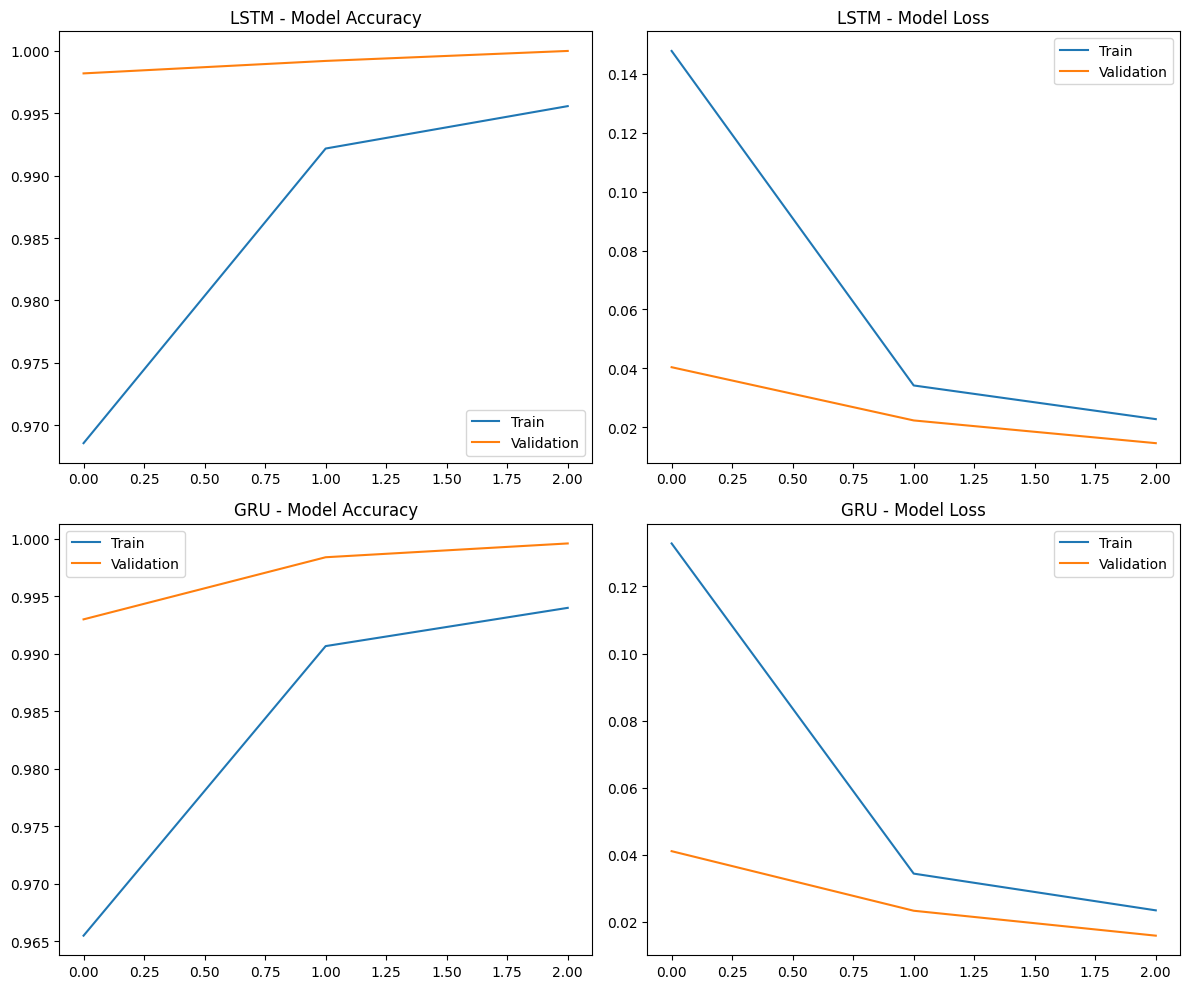

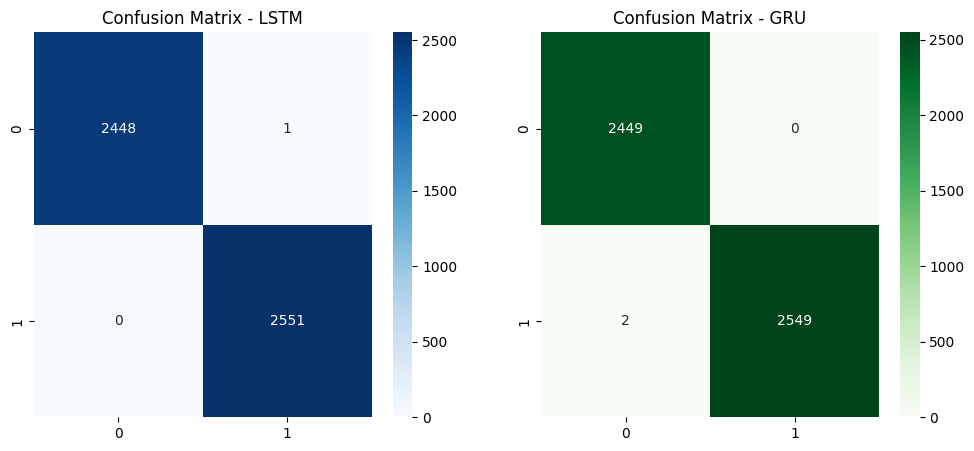

In [ ]:
# 7. EVALUASI & KOMPARASI
# Prediksi data uji
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype(int)
y_pred_gru = (model_gru.predict(X_test) > 0.5).astype(int)

# --- 1. Komparasi Metrik Evaluasi ---
metrics = {
    'Model': ['LSTM', 'GRU'],
    'Accuracy': [accuracy_score(y_test, y_pred_lstm), accuracy_score(y_test, y_pred_gru)],
    'Precision': [precision_score(y_test, y_pred_lstm), precision_score(y_test, y_pred_gru)],
    'Recall': [recall_score(y_test, y_pred_lstm), recall_score(y_test, y_pred_gru)],
    'F1 Score': [f1_score(y_test, y_pred_lstm), f1_score(y_test, y_pred_gru)]
}
df_metrics = pd.DataFrame(metrics)
display(df_metrics)

# --- 2. Visualisasi Grafik Akurasi & Loss ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Grafik LSTM
axes[0, 0].plot(history_lstm.history['accuracy'], label='Train')
axes[0, 0].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('LSTM - Model Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(history_lstm.history['loss'], label='Train')
axes[0, 1].plot(history_lstm.history['val_loss'], label='Validation')
axes[0, 1].set_title('LSTM - Model Loss')
axes[0, 1].legend()

# Grafik GRU
axes[1, 0].plot(history_gru.history['accuracy'], label='Train')
axes[1, 0].plot(history_gru.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('GRU - Model Accuracy')
axes[1, 0].legend()

axes[1, 1].plot(history_gru.history['loss'], label='Train')
axes[1, 1].plot(history_gru.history['val_loss'], label='Validation')
axes[1, 1].set_title('GRU - Model Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# --- 3. Confusion Matrix ---
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_gru = confusion_matrix(y_test, y_pred_gru)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - LSTM')
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - GRU')
plt.show()

In [ ]:
#8. OUTPUT GUI


# Berdasarkan hasil evaluasi, model LSTM memiliki performa terbaik
# sehingga model LSTM dipilih untuk diimplementasikan ke aplikasi GUI.

import tensorflow as tf

# Konversi model LSTM ke format TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model_lstm)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Mengizinkan TensorFlow Lite menggunakan operasi TensorFlow yang diperlukan
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# Mengatasi error TensorList pada model RNN
converter._experimental_lower_tensor_list_ops = False
converter.experimental_enable_resource_variables = True

# Konversi model
tflite_model = converter.convert()

# Simpan model
with open("model_prediksi_banjir.tflite", "wb") as f:
    f.write(tflite_model)

print("Sukses! Model LSTM berhasil disimpan sebagai model_prediksi_banjir.tflite")

Saved artifact at '/tmp/tmpyg_0we7p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1, 20), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138780761602384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780761602768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780761602960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780769706896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780761602576: TensorSpec(shape=(), dtype=tf.resource, name=None)
Sukses! Model LSTM berhasil disimpan sebagai model_prediksi_banjir.tflite


In [ ]:
from google.colab import files

files.download("model_prediksi_banjir.tflite")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>